In [1]:
import os
import time
import glob
#import opensimplex

#from torchvision.utils import save_image

import matplotlib.pyplot as plt
import numpy as np
import csv
import torch
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, Dataset
from monai.utils import set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import autocast
from tqdm import tqdm
import random

import nibabel as nib

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler

import pandas as pd
import AnoDDPM.simplex as simplex

from monai.metrics import compute_iou

from monai.utils import StrEnum
from typing import Union

from monai.metrics import PSNRMetric, SSIMMetric, MultiScaleSSIMMetric

/home/fehrdelt/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:

DEVICE_TYPE = "cuda:0"

ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

set_determinism(0)

IMAGE_SIZE = 128

In [3]:

class Get2DSlice(transforms.Transform):
    """
    Fetch the middle slice of a 3D volume.
    Args:
        axis: The axis along which to slice the volume. 0 for axial, 1 for coronal, 2 for sagittal.
        offset : Offset the index by a specified amount (default=0)
    """

    def __init__(
        self,
        axis: int = 0,
        offset: int=0
    ):
        super().__init__()
        self.axis = axis
        self.offset = offset

    def __call__(self, data):
        #print(data.shape)
        if self.axis==0:
            return data[:, data.shape[1]//2+self.offset,:,:]
        elif self.axis==1:
            return data[:, :,data.shape[2]//2+self.offset,:]
        elif self.axis==2:
            return data[:, :, :,data.shape[3]//2+self.offset]

class SetBackgroundToZero(transforms.Transform):
    """
    Custom MONAI transform that zeros out voxels with the most frequent intensity value.
    
    Args:
        keys (str or list): Keys of the dictionary to apply the transform to.
        tolerance (int): Optional range around the mode value to also zero.
    """
    def __init__(self, tolerance: int = 0):
        super().__init__()
        self.tolerance = tolerance

    def __call__(self, data):
        
            
        is_tensor = isinstance(data, torch.Tensor)
        data_np = data.cpu().numpy() if is_tensor else data

        # Flatten and compute histogram
        flat = data_np.flatten()
        unique, counts = np.unique(flat, return_counts=True)
        mode_val = unique[np.argmax(counts)]

        # Apply tolerance if specified
        if self.tolerance > 0:
            mask = np.isin(data_np, range(mode_val - self.tolerance, mode_val + self.tolerance + 1))
        else:
            mask = data_np == mode_val

        # Zero out the background
        data_np[mask] = 0

        # Put back in original type
        data = torch.from_numpy(data_np) if is_tensor else data_np

        return data

In [4]:

def generate_simplex_noise(simplexObj, shape):
    """Generate spatially correlated simplex noise."""

    simplexObj.newSeed()

    if len(shape) ==2:
        # take a slice t from the 3-dimensional noise function as we found that artefacts 
        # were introduced when sampling from the 2-dimensional noise function
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[0], shape[1]), octaves=6, persistence=0.8, frequency=64)[12,...]
    elif len(shape) == 3:
        simplex = simplexObj.rand_3d_octaves(shape=shape, octaves=6, persistence=0.8, frequency=64)
    elif len(shape) == 4 and shape[1] == 1: # to make it work with shapes of type (batch_size, 1, height, width)
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[2], shape[3]), octaves=6, persistence=0.8, frequency=64)
        simplex = np.expand_dims(simplex, axis=1)

    return torch.tensor(simplex, dtype=torch.float32)



In [5]:

class DDPMPredictionType(StrEnum):
    """
    Set of valid prediction type names for the DDPM scheduler's `prediction_type` argument.

    epsilon: predicting the noise of the diffusion process
    sample: directly predicting the noisy sample
    v_prediction: velocity prediction, see section 2.4 https://imagen.research.google/video/paper.pdf
    """

    EPSILON = "epsilon"
    SAMPLE = "sample"
    V_PREDICTION = "v_prediction"

class SimplexDDPMScheduler(DDPMScheduler):
    def __init__(self, *args, noise_scale=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.noise_scale = noise_scale
        self.simplex_obj = simplex.Simplex_CLASS()
        self.simplex_obj.newSeed()

    #def step(
    #    self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: torch.Generator | None = None
    #) -> tuple[torch.Tensor, torch.Tensor]:
    def step(
        self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: Union[torch.Generator, None] = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Predict the sample at the previous timestep by reversing the SDE. Core function to propagate the diffusion
        process from the learned model outputs (most often the predicted noise).

        Args:
            model_output: direct output from learned diffusion model.
            timestep: current discrete timestep in the diffusion chain.
            sample: current instance of sample being created by diffusion process.
            generator: random number generator.

        Returns:
            pred_prev_sample: Predicted previous sample
        """
        if model_output.shape[1] == sample.shape[1] * 2 and self.variance_type in ["learned", "learned_range"]:
            model_output, predicted_variance = torch.split(model_output, sample.shape[1], dim=1)
        else:
            predicted_variance = None

        # 1. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[timestep - 1] if timestep > 0 else self.one
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        # 2. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (15) from https://arxiv.org/pdf/2006.11239.pdf
        if self.prediction_type == DDPMPredictionType.EPSILON:
            pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
        elif self.prediction_type == DDPMPredictionType.SAMPLE:
            pred_original_sample = model_output
        elif self.prediction_type == DDPMPredictionType.V_PREDICTION:
            pred_original_sample = (alpha_prod_t**0.5) * sample - (beta_prod_t**0.5) * model_output

        # 3. Clip "predicted x_0"
        if self.clip_sample:
            pred_original_sample = torch.clamp(
                pred_original_sample, self.clip_sample_values[0], self.clip_sample_values[1]
            )

        # 4. Compute coefficients for pred_original_sample x_0 and current sample x_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_original_sample_coeff = (alpha_prod_t_prev ** (0.5) * self.betas[timestep]) / beta_prod_t
        current_sample_coeff = self.alphas[timestep] ** (0.5) * beta_prod_t_prev / beta_prod_t

        # 5. Compute predicted previous sample µ_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_prev_sample = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * sample

        # 6. Add noise
        variance: torch.Tensor = torch.tensor(0)
        if timestep > 0:
            self.simplex_obj.newSeed()
            noise = generate_simplex_noise(self.simplex_obj, shape=model_output.size()).to(model_output.device)
            
            """ #TODO
            noise = torch.randn(
                model_output.size(),
                dtype=model_output.dtype,
                layout=model_output.layout,
                generator=generator,
                device=model_output.device,
            )"""
            variance = (self._get_variance(timestep, predicted_variance=predicted_variance) ** 0.5) * noise

        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample, pred_original_sample


In [6]:

device = torch.device(DEVICE_TYPE)
simplexObj = simplex.Simplex_CLASS()


model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(128, 128, 256, 256),
    attention_levels=(False, True, True, True),
    num_head_channels=(0, 128, 128, 256),
)
model.to(device)


num_train_timesteps = 1000
scheduler = SimplexDDPMScheduler(num_train_timesteps=num_train_timesteps)

optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)


model.load_state_dict(torch.load(os.path.join(ROOT_DIR+"AnoDiffExperiments/best_models/experiment_3", "exp_3_6_best_model.pth"), map_location=DEVICE_TYPE))
model.eval()

DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler

In [7]:


@torch.no_grad()
def my_sample(image, timesteps=100, progress_bar=True, return_first_noisy_image=False):
    
    
    num_infer_timesteps = timesteps #100 # higher number = more noise at first timestep, more denoising steps
    
    infer_scheduler = SimplexDDPMScheduler(num_train_timesteps=num_infer_timesteps)

    all_next_timesteps = torch.cat((scheduler.timesteps[1:], torch.tensor([0], dtype=infer_scheduler.timesteps.dtype)))

    first_noisy_image = torch.zeros_like(image)

    if progress_bar:
        progress_bar = tqdm(
            zip(infer_scheduler.timesteps, all_next_timesteps),
            total=min(len(infer_scheduler.timesteps), len(all_next_timesteps)),
        )
    else:
        progress_bar = zip(infer_scheduler.timesteps, all_next_timesteps)
            
            
    for t, next_t in progress_bar: # va de num_infer_timesteps à 0
        # 1. predict noise model_output
        diffusion_model = model
        
        model_output = diffusion_model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
        # 2. compute previous image: x_t -> x_t-1
        
        image, _ = infer_scheduler.step(model_output, t, image)

        if t == num_infer_timesteps-1:
            first_noisy_image = image

    if return_first_noisy_image:
        return image, first_noisy_image
    else:
        return image


In [151]:

test_reconstruction_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/final_adc_dataset_small_with_augmentation_by_registration/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        test_reconstruction_images_path.append(ROOT_DIR+line[0])

#val_datalist = sorted(val_images_path)
test_reconstruction_datalist = test_reconstruction_images_path

#test_unhealthy_datalist = test_unhealthy_images_path

batch_size = 16
num_workers = 4

test_reconstruction_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(IMAGE_SIZE, IMAGE_SIZE)),
        SetBackgroundToZero()
    ]
)
test_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist[:batch_size], transform=test_reconstruction_transforms) #TODO test_reconstruction_datalist[:batch_size]
test_reconstruction_loader = DataLoader(
    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)


205it [00:00, 650.62it/s]
Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:04<00:00,  3.82it/s]


In [169]:

NOISE_MIN = 300
NOISE_MAX = 601
NOISE_RANGE = range(NOISE_MIN,NOISE_MAX,50)

ssim_metric = SSIMMetric(spatial_dims=2, data_range=1.0)
psnr_metric = PSNRMetric(max_val=1.0)

mse = {noise: [] for noise in NOISE_RANGE} # for each noise level there is a list of mse values
psnr = {noise: [] for noise in NOISE_RANGE}
ssim = {noise: [] for noise in NOISE_RANGE}

for image_batch in tqdm(test_reconstruction_loader): #TODO for now this works only if there are less images than batch size

    test_images = image_batch.to(device)

    with autocast(device_type=DEVICE_TYPE, enabled=True):
        # Perform 5 inferences and average the results
        infered_images = []

        for i, noise_timesteps in enumerate(NOISE_RANGE):

            print(f"inference for {noise_timesteps} noise timesteps")

            infered, first_noisy_images = my_sample(test_images, timesteps=noise_timesteps, progress_bar=False, return_first_noisy_image=True)


            mse[noise_timesteps].append(F.mse_loss(infered, test_images).detach().cpu().numpy().flatten())
            ssim[noise_timesteps].append(np.mean(ssim_metric(test_images, infered).detach().cpu().numpy().flatten()))
            psnr[noise_timesteps].append(psnr_metric(infered, test_images).detach().cpu().numpy().flatten())


  0%|                                                                                                                                               | 0/1 [00:00<?, ?it/s]

inference for 300 noise timesteps
inference for 350 noise timesteps
inference for 400 noise timesteps
inference for 450 noise timesteps
inference for 500 noise timesteps
inference for 550 noise timesteps
inference for 600 noise timesteps


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [17:36<00:00, 1056.98s/it]


### Visualisation

In [153]:
infer_timesteps = NOISE_MIN+NOISE_MAX//2

for i,(image_batch) in enumerate(test_reconstruction_loader):
    if i>0:break

    test_images = image_batch.to(device)

    with autocast(device_type=DEVICE_TYPE, enabled=True):
        infered_images = []
        infered, first_noisy_images = my_sample(test_images, timesteps=infer_timesteps, progress_bar=False, return_first_noisy_image=True)
    

The figure layout has changed to tight


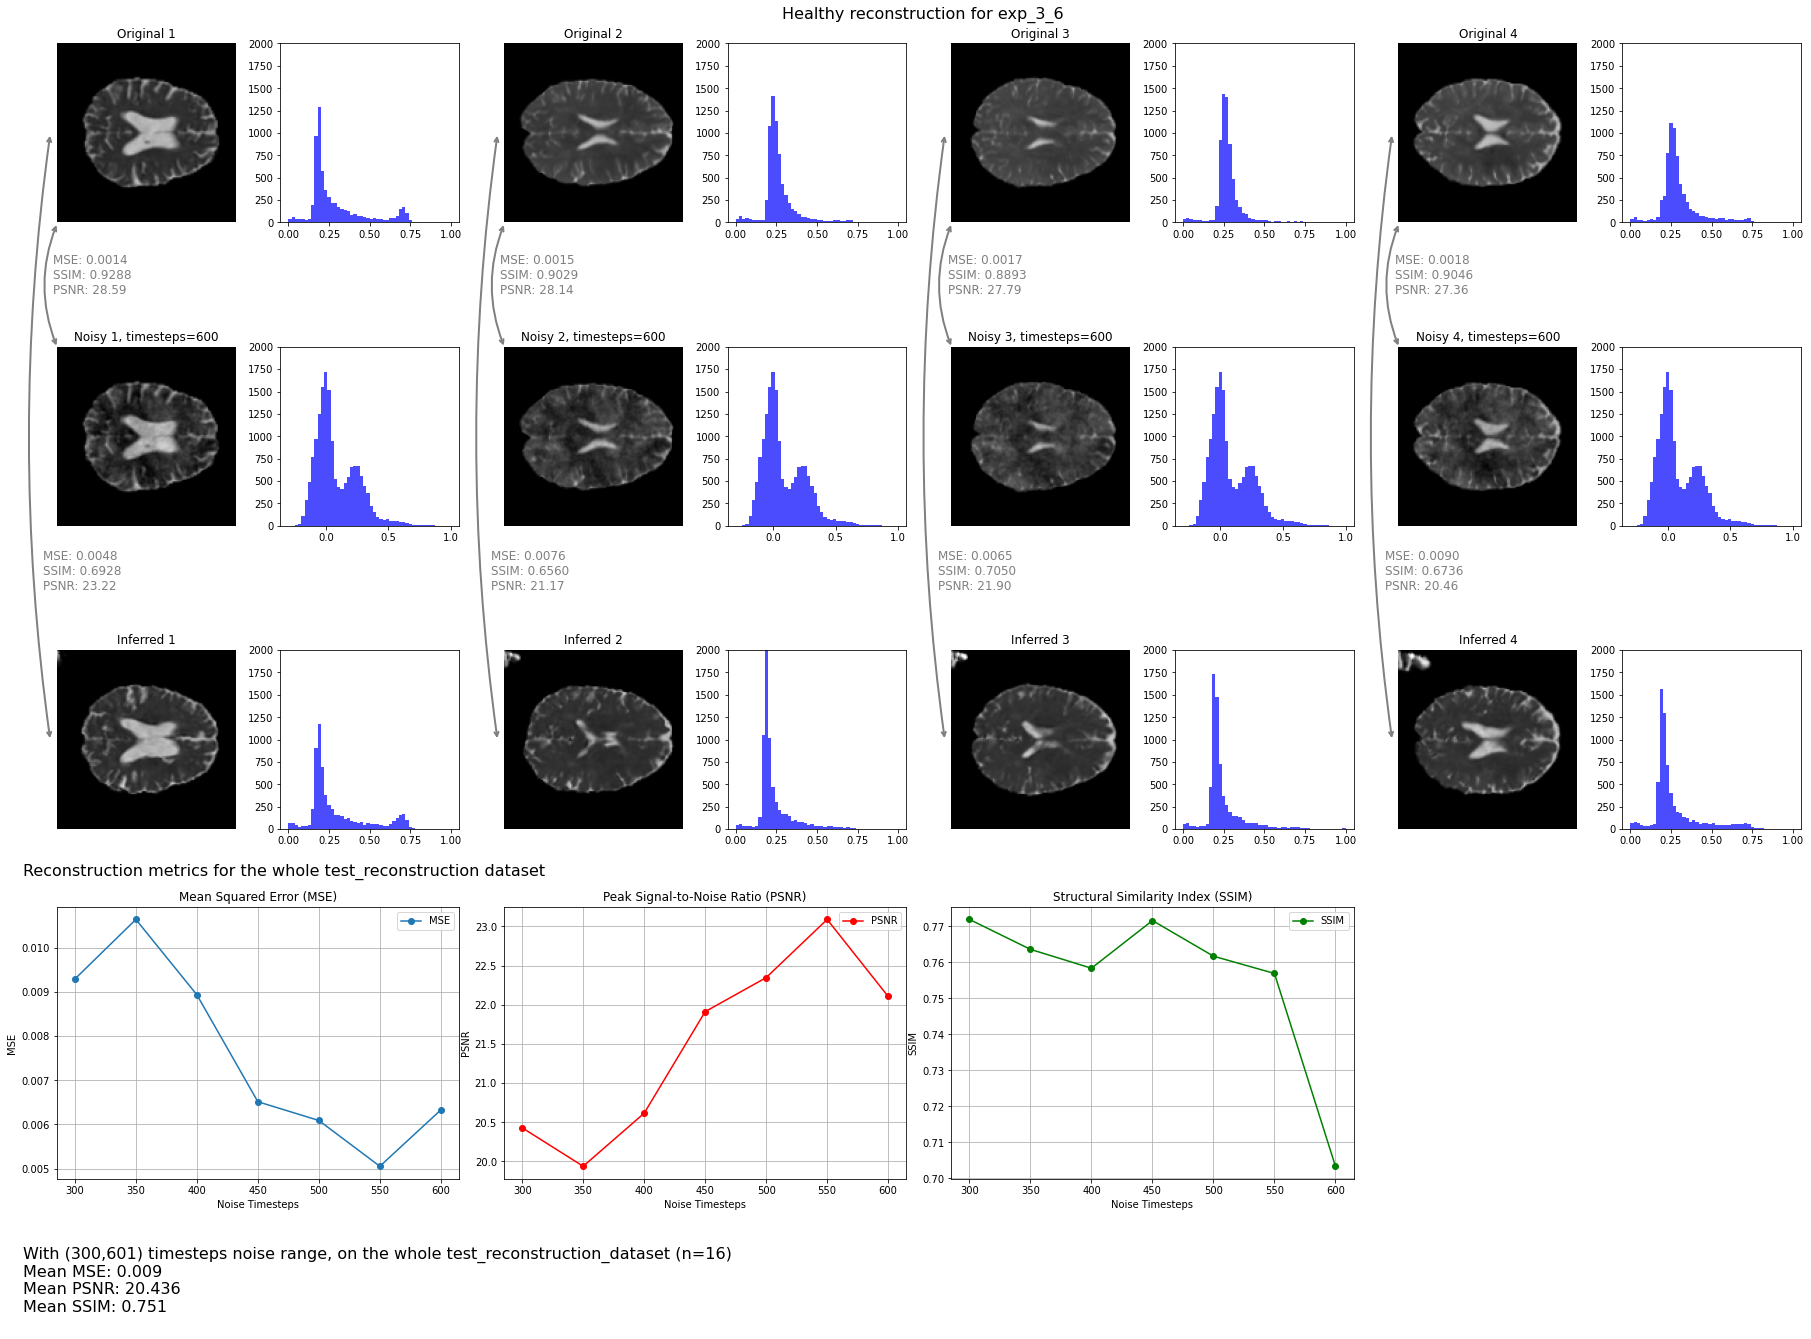

In [170]:



EXPERIMENT_NAME = "exp_3_6"

metric_result_text = f"With ({NOISE_MIN},{NOISE_MAX}) timesteps noise range, on the whole test_reconstruction_dataset (n={batch_size})\n"
metric_result_text += f"Mean MSE: {np.mean(mse_list[0]):.3f}\n"
metric_result_text += f"Mean PSNR: {np.mean(psnr_list[0]):.3f}\n"
metric_result_text += f"Mean SSIM: {np.mean(ssim_list):.3f}\n"


plt.rcParams['axes.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'

TEXTCOLOR = 'black'
plt.rcParams['text.color'] = TEXTCOLOR
plt.rcParams['axes.labelcolor'] = TEXTCOLOR
plt.rcParams['xtick.color'] = TEXTCOLOR
plt.rcParams['ytick.color'] = TEXTCOLOR

fig, axes = plt.subplots(4, 8, figsize=(25, 17), constrained_layout=True)
plt.tight_layout()

for idx in range(min(4, test_images.shape[0])):

    # Original test images
    original_image = test_images[idx, 0].cpu().numpy()
    axes[0, idx*2].imshow(original_image, cmap='gray', vmin=0, vmax=1)
    axes[0, idx*2].set_title(f'Original {idx+1}')
    axes[0, idx*2].axis('off')

    axes[0, idx*2+1].hist(original_image[original_image>0.01].flatten(), bins=50, color='blue', alpha=0.7, range=(0.0, 1.0))
    axes[0, idx*2+1].set_ylim(0, 2000)
    axes[0, idx*2+1].set_aspect('auto')  # Set the aspect ratio to auto to match the imshow plot
    
    
    # First noisy images

    first_noisy_image_no_background = first_noisy_images[idx, 0].cpu().numpy().copy()
    first_noisy_image_no_background[original_image < 0.01] = 0.0
    

    #axes[1, idx*2].imshow(noisy_image, cmap='gray', vmin=0, vmax=1)
    axes[1, idx*2].imshow(first_noisy_image_no_background, cmap='gray', vmin=0, vmax=1)
    axes[1, idx*2].set_title(f'Noisy {idx+1}, timesteps={infer_timesteps}')
    axes[1, idx*2].axis('off')

    axes[1, idx*2+1].hist(noisy_image.flatten(), bins=50, color='blue', alpha=0.7, range=(-0.3, 1.0))
    axes[1, idx*2+1].set_ylim(0, 2000)
    axes[1, idx*2+1].set_aspect('auto')  # Set the aspect ratio to auto to match the imshow plot

    # Inferred images
    infered_image = infered[idx, 0].cpu().numpy()
    axes[2, idx*2].imshow(infered_image, cmap='gray', vmin=0, vmax=1)
    axes[2, idx*2].set_title(f'Inferred {idx+1}')
    axes[2, idx*2].axis('off')

    axes[2, idx*2+1].hist(infered_image[infered_image>0.01].flatten(), bins=50, color='blue', alpha=0.7, range=(0.0, 1.0))
    axes[2, idx*2+1].set_ylim(0, 2000)
    axes[2, idx*2+1].set_aspect('auto') # Set the aspect ratio to auto to match the imshow plot
    axes[0, idx*2+1].set_box_aspect(1)  # Set the aspect ratio of the histogram subplot
    axes[1, idx*2+1].set_box_aspect(1)  # Set the aspect ratio of the histogram subplot
    axes[2, idx*2+1].set_box_aspect(1)  # Set the aspect ratio of the histogram subplot

    # Arrow from original image to noisy image
    axes[0, idx*2].annotate( 
        '', xy=(0.0, 128), xycoords=axes[0, idx*2].transData,
        xytext=(0.0, 0), textcoords=axes[1, idx*2].transData,
        arrowprops=dict(arrowstyle="<->", color='grey', lw=2, connectionstyle="arc3, rad=-0.2")
    )
    true = test_images[idx, 0].unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    noisy = torch.from_numpy(first_noisy_image_no_background).to(device).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions   
    text_metrics_orig_and_noisy = f"MSE: {F.mse_loss(true, noisy).detach().cpu().numpy().mean():.4f}\n"
    text_metrics_orig_and_noisy += f"SSIM: {np.mean(ssim_metric(true, noisy).detach().cpu().numpy().mean()):.4f}\n"
    text_metrics_orig_and_noisy += f"PSNR: {psnr_metric(true, noisy).detach().cpu().numpy().mean():.2f}"

    axes[0, idx*2].text(
        -3, 165, text_metrics_orig_and_noisy, transform=axes[0, idx*2].transData, #TODO first_noisy_images[idx, 0])
        color='grey', fontsize=12, verticalalignment='center'
    )


    # Arrow from original image to infered image
    axes[0, idx*2].annotate(
        '', xy=(-5, 64), xycoords=axes[0, idx*2].transData, #'axes fraction',
        xytext=(-5, 64), textcoords=axes[2, idx*2].transData,
        arrowprops=dict(arrowstyle="<->", color='grey', lw=2, connectionstyle="arc3, rad=-0.07")
    )

    pred = infered[idx, 0].unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions   
    text_metrics_orig_and_pred = f"MSE: {F.mse_loss(true, pred).detach().cpu().numpy().mean():.4f}\n"
    text_metrics_orig_and_pred += f"SSIM: {np.mean(ssim_metric(true, pred).detach().cpu().numpy().mean()):.4f}\n"
    text_metrics_orig_and_pred += f"PSNR: {psnr_metric(true, pred).detach().cpu().numpy().mean():.2f}"


    axes[2, idx*2].text(
        -10, 160, text_metrics_orig_and_pred, transform=axes[1, idx*2].transData,
        color='grey', fontsize=12, verticalalignment='center'
    )

# Add overall title with metric results
plt.suptitle(f"Healthy reconstruction for {EXPERIMENT_NAME}", fontsize=16)

plt.figtext(0.0, -0.1, metric_result_text, fontsize=16)

plt.figtext(0.0, 0.27, "Reconstruction metrics for the whole test_reconstruction dataset", fontsize=16)

for ax in axes[3, 0:2]: # two merge two subplots
    ax.remove()
gs = axes[3, 0].get_gridspec()
axbig1 = fig.add_subplot(gs[3, 0:2])

# MSE plot
axbig1.plot(NOISE_RANGE, [np.mean(mse[noise]) for noise in NOISE_RANGE], marker='o', label='MSE')
axbig1.set_title('Mean Squared Error (MSE)')
axbig1.set_xlabel('Noise Timesteps')
axbig1.set_ylabel('MSE')
axbig1.grid(True)
axbig1.legend()

for ax in axes[3, 2:4]:
    ax.remove()
gs = axes[3, 4].get_gridspec()
axbig2 = fig.add_subplot(gs[3, 2:4])


# PSNR plot
axbig2.plot(NOISE_RANGE, [np.mean(psnr[noise]) for noise in NOISE_RANGE], marker='o', label='PSNR', color='red')
axbig2.set_title('Peak Signal-to-Noise Ratio (PSNR)')
axbig2.set_xlabel('Noise Timesteps')
axbig2.set_ylabel('PSNR')
axbig2.grid(True)
axbig2.legend()

for ax in axes[3, 4:6]:
    ax.remove()
gs = axes[3, 2].get_gridspec()
axbig3 = fig.add_subplot(gs[3, 4:6])

# SSIM plot
axbig3.plot(NOISE_RANGE, [np.mean(ssim[noise]) for noise in NOISE_RANGE], marker='o', label='SSIM', color='green')
axbig3.set_title('Structural Similarity Index (SSIM)')
axbig3.set_xlabel('Noise Timesteps')
axbig3.set_ylabel('SSIM')
axbig3.grid(True)
axbig3.legend()




fig.delaxes(axes[3,6])
fig.delaxes(axes[3,7])

plt.savefig(f"experiment_3/{EXPERIMENT_NAME}_metrics_reconstruction.png", transparent=False, dpi=150)
plt.show()

